In [1]:
#import packages
import time
import numpy as np
from typing import *
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import plotly.graph_objects as go
from scipy.interpolate import splprep, splev
import csv
import os
import SantecTunableLaser
from NIDAQ import USB6363
import nidaqmx
from nidaqmx.constants import AcquisitionType
from nidaqmx.constants import Edge

from src.DieTesterInstrument import *
from src.FirstLightController import *
from src.ChipAlignmentController import ChipAlignmentController
from src.NIDAQPowermeter import PowermeterSystem
from src.SoftwareFence import SoftwareFence
# from NIDAQ import USB6363
#list ASRLs
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources() # to make sure all the Suruga stages are connected

('USB0::0x0957::0x3718::MY51350815::INSTR',
 'ASRL23::INSTR',
 'ASRL24::INSTR',
 'ASRL25::INSTR',
 'ASRL26::INSTR')

In [2]:
#@ Die Tester Stage and Powermeter + Motion I/O

try:
    stg.close()
    pm.close()
    time.sleep(1)
    del stg
    del pm
except:
    0

stg = DieTesterStage(23, 26, 24, 25)
# stg = DieTesterStage(19, 20, 21, 22) # before moving: 13, 15, 5, 4
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) # needs Dev1 for the raster to work

Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
Connected to: SURUGA,DS102,0,VER4.00
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


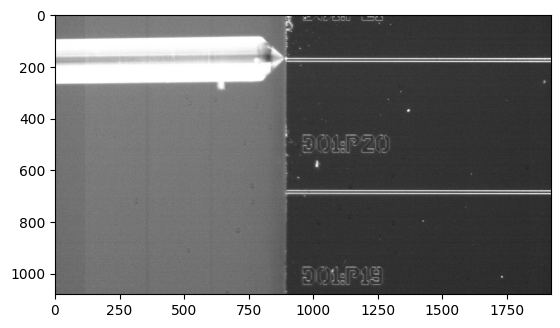

In [3]:
## OBS Virtual Camera (Make sure its on and that you have the correct name)
%matplotlib inline
def clear_interface():
    plt.close('all')
    clear_output(wait=True)

cap = RealtimeVideoCapture(3)  # Change to whatever index your OBS camera is. 
time.sleep(1)

clear_interface()
plt.imshow(cap.mean_capture(10, convert_to_grayscale=False))
plt.show()

In [4]:
flc = FirstLightController(pm, stg)
cac = ChipAlignmentController(stg, cap)
fence = SoftwareFence(stg, cap)

Manually align the fibers in x, y and z
Move fibers to a safe location

In [ ]:
# MANUALLY ALIGN THE FIBERS, TO DO THIS: raise the fibers, bring it closer, 
# change x to bring the fibers into field of view of camera, move back the fiber and bring it 
# down into the focus of camera
# MOVE FIBERS BACK TO A SAFE LOCATION
## Enter whatever commands you need to do this
stg.set_speed('r', 9)
stage = 'l'
stg.move_relative(stage, 'z', -500, wait=True)

In [6]:
stage = 'r'
stg.move_relative(stage, 'z', -1000, wait=True)

# # Save safe positions (or at least print them out).
# l_safe_position = stg.query_position('l')
# print(l_safe_position)
# r_safe_position = stg.query_position('r')
# print(r_safe_position)

CHIP ALIGNMENT

In [ ]:
# CHIP ALIGNMENT
## Move chip (and camera) so that the top or bottom calibration patterns are visible in the camera, roughly in the middle.
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -9000, wait=True)# -9000 or 9000 to move it

In [ ]:
## Run to open template selection widget and draw a bounding box around the pattern or alignment mark.
%matplotlib widget

img = cap.mean_capture(20)
clear_interface()
cac.new_template_selection(img)

In [ ]:
## Save the template to the alignment controller
%matplotlib inline

template_image = cac.generate_template(img)
clear_interface()
plt.imshow(template_image)
plt.scatter(template_image.shape[1] / 2, template_image.shape[0] / 2, c='r')
plt.show()

In [105]:
# move the chip to see the other alignment mark and bring it back
stg.set_speed('m', 9)
stg.move_relative('m', 'X', 8, wait=True)# -10000 or 10000, TFLN 9000, b/w adjacent wvgs 6 um; wvg sets 381um
#remember to move it back and not to redefine the template

In [ ]:
%matplotlib inline
## Select your movement values and perform chip alignment.
# Large movement should be roughly the length of the chip (1 cm works well), small calibration movement should be a few hundred microns.
#   - Make sure that the small movement doesn't bring your calibration pattern out of frame
# The sign of the movements should be positive for moving from top to bottom, and negative for moving bottom to top.


mainX = 9_000  # main movement (width of chip), 10_000 original
calX = 500  # calibration movement, 500 before
deg = cac.run_angle_calibration(mainX, calX, camera_focus_prompt=True) 

In [ ]:
## If angle seems reasonable, rotate to align chip
# Check the pattern centers in the images for reasonableness
stg.move_relative_rotation(deg) # deg

COARSE FIBER ALIGNMENT MANUALLY

In [552]:
## Perform this for both the left and right stages. ('l' and 'r')
stage = 'l'
stage

'l'

In [553]:
## Do whatever commands you need to move the left/right fiber into the frame and in focus.
stg.move_relative(stage, 'z', -2, wait=True)#moved 40, -30
# change the height of fibers manually using a fault detector to see light through the waveguide
#for both left and right


In [580]:
# rout2 for ultrafast setup
route_no = '2'# For two channels rout1 or rout2
output_port = '1'

switch.write('rout' + route_no + ':chan1 A,' + output_port)

17

FIRST LIGHT

In [5]:
import importlib
import src.FirstLightController
importlib.reload(src.FirstLightController)
from src.FirstLightController import *

flc = FirstLightController(pm, stg)

In [6]:
#switch

address = 'USB0::0x0957::0x3718::MY51350815::INSTR' # N7731A
# address = 'USB0::0x0957::0x3718::MY51350266::INSTR' # N7734A 

rm = pyvisa.ResourceManager()
switch = rm.open_resource(address)
switch.timeout = 5000 

# Verify Connection to the switch
idn = switch.query('*IDN?')
print(f"Connected to: {idn}")

Connected to: Keysight Technologies, N7731A, MY51350815, 1.21



In [534]:
route_no = '1'# For two channels rout1 or rout2
output_port = '3'

switch.write('rout' + route_no + ':chan1 A,' + output_port)

17

In [535]:
ai_channel = 'ai2'#, 'ai3', 'ai4', 'ai5']
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg)

AIChannel(name=Dev1/ai2)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)


In [564]:
### Broad scan, can make it small scan with generate_linear_spiral((5, 5), 10)
stage = 'r'
line_numbers = [0, 1, 2]    # motion i/o for left XY, right XY, all Z (works assuming both fibers don't move at the same time)
speed = 7# 7                  # Speed setting from 0-9. Higher is only faster to a point.
# ai_channel = 'ai1'

broad_range = False
if broad_range == True:
    commands = flc.pgen.generate_linear_spiral((20, 20), 40)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
else:
    commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
# commands = flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = True)

datapoints = result['datapoints']

# Not plotting the distribution
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]
print(f"Maximum: {max_point}")

fig.show()

Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  5.89item/s]


Returning to original position...
Fitting gaussian regression to datapoints...
Found optimal parameters.
Mean: [ 0.03015587 -0.04825691]
Cov: [[10.05732698  0.3113517 ]
 [ 0.3113517  11.65362925]]
Maximum: [-0.5         0.28453039]


In [565]:
# Move to the gaussian fit mean

mean = result['mean']
stg.move_relative(stage, 'X', mean[0])#mean[0])
stg.move_relative(stage, 'Y', mean[1])#mean[1])
print(f"Moved to {mean}")

Moved to [ 0.03015587 -0.04825691]


In [ ]:
x0, y0 = raster_fit(datapoints)
print(x0, y0)

In [ ]:
stage = 'r'
stg.move_relative(stage, 'z', -1000)

In [ ]:
# 0.075/(3e4 * 0.45)
np.max(datapoints[:,2]) # 4.726, 27.2 mV in Si @ gain = 3e4 
np.max(datapoints[:,2]/(0.55*10))# 4.51V @ gain = 10
# out of Pm1550, 0.859 mW? in InGaAs

In [14]:
xy_points = datapoints[:, 0:2]
P_points = datapoints[:, 2]

def gaussian_fit_func(xy, a, x0, sigxsq, y0, sigysq):
    x = xy[:,0]
    y = xy[:,1]
    return a * np.exp(-((x-x0)**2/sigxsq + (y-y0)**2/sigysq))

# fitting a 2d gaussian
p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

[fitparams, fitcov] = curve_fit(gaussian_fit_func, xy_points, P_points, p0)
fitcov
fit_gauss = gaussian_fit_func(xy_points, *fitparams)

fig = go.Figure()
fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=P_points,
                                   mode='markers', marker=dict(
                size=2,          # Marker size in pixels
                color='blue',      # Marker color
                opacity=0.8,      # Transparency
                symbol='circle'   # Marker shape
            )))
fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=fit_gauss, marker=dict(
                size=2,          # Marker size in pixels
                color='red',      # Marker color
                opacity=0.8,      # Transparency
                symbol='circle'   # Marker shape
            )))
fig.show()

x0 = fitparams[1]
y0 = fitparams[3]
print(x0, y0)

# fig = plt.figure()
# # Use 'projection="3d"' to enable 3D plotting
# ax = fig.add_subplot(111, projection='3d')

# # Plot the scatter points
# ax.scatter(xy_points[:,0], xy_points[:,1], P_points, 'o', s = 0.4)
# ax.scatter(xy_points[:,0], xy_points[:,1], fit_gauss)
# fig.show()



0.849679628622289 -0.06810947768313248


In [21]:
fitparams[4]

np.float64(19.506268865023067)

In [ ]:
x0 = fitparams[1]
y0 = fitparams[3]
stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)
print(f"Moved to {[x0, y0]}")

In [ ]:
print(result['mean']) # - np.array(fitparams[1], fitparams[3])
print(np.array((fitparams[1], fitparams[3]))) # center which is the max point of gaussian
print(result['mean'] - np.array(fitparams[1], fitparams[3]))


check if there's difference in programming time with or without regression & separate fits

Config file to define parameters; eg linenumbers indicating DAQ ports and which axes of controller to move

Separate left and right moving stages as objects, so don't have to define 'l' and 'r' as arguments each time.

In [ ]:
# commands = flc.pgen.generate_linear_spiral((2.5, 2.5), 10)
# np.shape(datapoints)
# plt.plot(datapoints[:,2])

In [560]:
## Z fine-tuning
stage = 'r'
line_numbers = [0, 1, 2] # left XY, right XY, all Z
speed = 2

# Enter a list of relative commands manually, comes back to original position
commands = [
    ['Z', 1],#2
    ['Z', 0], #-8
]
result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

datapoints = result['datapoints']
fig = result['figure']

## Maximum point delta
max_point = datapoints[
    np.argmax(datapoints[:, 2])
][:2]

fig.show()

Starting motion...


Current Move: (Z, 0.0): 100%|██████████| 2/2 [00:00<00:00,  4.96item/s]


Returning to original position...


In [ ]:
# # do the same raster scan for 'r'
# z_tun = datapoints[:,0]
# Pz_tun = datapoints[:,2]

# plt.plot(z_tun, Pz_tun, 'o')

# from scipy.interpolate import splprep, splev
# tck, u = splprep([z_tun, Pz_tun], s=40, k = 5)
# new_points = splev(u, tck)
# plt.plot(new_points[0], new_points[1])
# print(new_points[0][np.argmax(new_points[1])])

# stg.move_relative(stage, 'Z', new_points[0][np.argmax(new_points[1])])

0.0


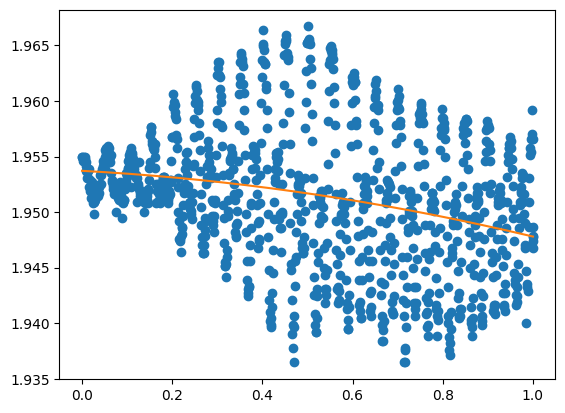

In [561]:
# do the same raster scan for 'r'
z_tun = datapoints[:,0]
Pz_tun = datapoints[:,2]

plt.plot(z_tun, Pz_tun, 'o')

def parabola(x, a, b, c):
    return a*x + b* x**2 + c

# fitting a 2d gaussian
# p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

[fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
fitcov
fit_par = parabola(z_tun, *fitparams)

plt.plot(z_tun, fit_par)
print(z_tun[np.argmax(fit_par)])
stg.move_relative(stage, 'Z', z_tun[np.argmax(fit_par)])

In [483]:
stg.move_relative(stage, 'Z', -1)

Maybe even close to 20% fluctuations. from the fiber?

In [21]:
def pdToPow(x, g): # argument photodiode output volts from tap
    # g = 10 # gain setting
    R = 0.55 # responsivity, can interpolate the graph for more accurate values
    tap_pow = x/(g*R) # power in mW
    #act_pow = tap_pow*10*0.9*0.5 # 90/10 and 50/50 splitter output
    return tap_pow # in mW

# Interpolate to get the power in mW after the lensed fiber for a given tap output
tap_data = np.loadtxt(r"c:\Users\Lab1.6.NTTR-JB7LY33\Desktop\2026 - 01 - 16 - Code for TWM Tester\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows= 1)
# tap_data = np.loadtxt(r"c:\Users\Lab1.6.NTTR-JB7LY33\Desktop\2026 - 01 - 16 - Code for TWM Tester\characterization_data\lut_aftBOA267mA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)
idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
inp_pow = tap_data[idx,2]*1e3 # scaling
# 10*np.log10(pdToPow(0.713, 100)/(pdToPow(0.225, 1)*10*0.9*0.5))
# print('Insertion loss- ', 10*np.log10(pdToPow(np.max(datapoints[:,2]), 100)/inp_pow))
print('Insertion loss- ', 10*np.log10(pdToPow(np.max(datapoints[:,2]), 10)/inp_pow)) # 32

Insertion loss-  -22.295706925724666


In [ ]:
fitcov

In [22]:
def gaussian_fit_func(xy, a, x0, sigxsq, y0, sigysq):
    x = xy[:,0]
    y = xy[:,1]
    return a * np.exp(-((x-x0)**2/sigxsq + (y-y0)**2/sigysq))

def raster_fit(datapoints):

    xy_points = datapoints[:, 0:2]
    P_points = datapoints[:, 2]

    # fitting a 2d gaussian
    p0 = [1, 0, (xy_points[:,0].max() - xy_points[:,0].min())/2, 0, (xy_points[:,1].max() - xy_points[:,1].min())/2]

    [fitparams, fitcov] = curve_fit(gaussian_fit_func, xy_points, P_points, p0, maxfev=5000)
    fitcov
    fit_gauss = gaussian_fit_func(xy_points, *fitparams)

    # fig = go.Figure()
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=P_points,
    #                                 mode='markers', marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='blue',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.add_trace(go.Scatter3d(x=xy_points[:,0], y=xy_points[:,1], z=fit_gauss, marker=dict(
    #                 size=2,          # Marker size in pixels
    #                 color='red',      # Marker color
    #                 opacity=0.8,      # Transparency
    #                 symbol='circle'   # Marker shape
    #             )))
    # fig.show()

    x0 = fitparams[1]
    y0 = fitparams[3]

    if np.abs(x0) > 3.5 or np.abs(y0) > 7: # for safety if the fit is wrong
        x0 = y0 = 0
    
    print(f"Moved to {[x0, y0]}")
    print('Max is: ', np.max(P_points))

    return x0, y0



In [23]:


def raster_scan(stage, broad_range):
    if broad_range == True:
        commands = flc.pgen.generate_linear_spiral((10, 10), 20)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    else:
        commands = flc.pgen.generate_linear_spiral((5, 5), 10)    # params are scan dimension (should be x,y) and number of steps., (10,10,20)
    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']

    # fig = result['figure']

    # ## Maximum point delta
    # max_point = datapoints[
    #     np.argmax(datapoints[:, 2])
    # ][:2]
    # print(f"Maximum: {max_point}")

    # fig.show()

    # mean = result['mean']
    # stg.move_relative(stage, 'X', mean[0])
    # stg.move_relative(stage, 'Y', mean[1])
    # print(f"Moved to {mean}")

    return datapoints



In [24]:
def parabola(x, a, b, c):
    return a*x + b* x**2 + c

def z_scan(stage, broad_range):
    if broad_range == True:
        commands = [
        ['Z', 2],#2
        ['Z', 0], #-8
        ]
    else:
        commands = [
        ['Z', 1],#2
        ['Z', 0], #-8
        ]
        
    line_numbers = [0, 1, 2] # left XY, right XY, all Z
    speed = 6 # increased speed from 2

    result = flc.scan_path(stage, commands, speed, line_numbers, perform_regression = False)

    datapoints = result['datapoints']

    z_tun = datapoints[:,0]
    Pz_tun = datapoints[:,2]

    # fig = plt.figure('z_scan')
    # ax = fig.add_subplot(111)
    # plt.plot(z_tun, Pz_tun, 'o') # plotting for checking, remove in a loop
    
    # tck, u = splprep([z_tun, Pz_tun], s=40, k = 5)
    # new_points = splev(u, tck)
    # plt.plot(new_points[0], new_points[1])
    # # fig.show()
    
    # print(new_points[0][np.argmax(new_points[1])])

    # stg.move_relative(stage, 'z', new_points[0][np.argmax(new_points[1])], wait=True)

    # return new_points[0][np.argmax(new_points[1])]

    [fitparams, fitcov] = curve_fit(parabola, z_tun, Pz_tun) # p0
    fitcov
    fit_par = parabola(z_tun, *fitparams)

    # plt.plot(z_tun, fit_par)plotting for checking, remove in a loop
    print(z_tun[np.argmax(fit_par)])

    return z_tun[np.argmax(fit_par)]


In [242]:
def pdToPow(x, g): # argument photodiode output volts from tap
    # g = 10 # gain setting
    R = 0.55 # responsivity, can interpolate the graph for more accurate values
    tap_pow = x/(g*R) # power in mW
    #act_pow = tap_pow*10*0.9*0.5 # 90/10 and 50/50 splitter output
    return tap_pow # in mW

# Interpolate to get the power in mW after the lensed fiber for a given tap output
# tap_data = np.loadtxt(r"c:\Users\Lab1.6.NTTR-JB7LY33\Desktop\2026 - 01 - 16 - Code for TWM Tester\characterization_data\lut770_aftBOA267mA.csv", delimiter = ',', skiprows = 1)
tap_data = np.loadtxt(r"c:\Users\Lab1.6.NTTR-JB7LY33\Desktop\2026 - 01 - 16 - Code for TWM Tester\characterization_data\lut_aftBOA267mA_aftLensedFiber.csv", delimiter = ',', skiprows= 1)
idx = np.argmin(np.abs(tap_data[:,0] - 1.56e-6))
inp_pow = tap_data[idx,2]*1e3 # scaling
# 10*np.log10(pdToPow(0.713, 100)/(pdToPow(0.225, 1)*10*0.9*0.5))
# print('Insertion loss- ', 10*np.log10(pdToPow(np.max(datapoints[:,2]), 100)/inp_pow))

In [ ]:
10*np.log10(pdToPow(np.max(datapoints[:,2]), 1000)/inp_pow)

In [26]:
def fine_tun():
    z_trans_l = z_scan('l', True) # False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_l)
    stage = 'l'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    z_trans_r = z_scan('r', True)# False?
    # time.sleep(0.75)
    stg.move_relative('l', 'Z', z_trans_r)
    stage = 'r'
    raster_data = raster_scan(stage, False)
    x0, y0 = raster_fit(raster_data)
    stg.move_relative(stage, 'X', x0)
    stg.move_relative(stage, 'Y', y0)

    return raster_data, z_trans_l, z_trans_r

In [569]:
# Moved to [np.float64(-883.8322536776053), np.float64(-70.33244976197754)]
stage = 'r'
stage
# move fibers front initially
stg.move_relative(stage, 'z', -1000, wait=True)

In [ ]:
stage = 'r'
raster_data = raster_scan(stage, False)
x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

In [ ]:
z_trans = z_scan('r', True)
# time.sleep(0.75)
stg.move_relative('r', 'Z', z_trans, wait = True)

In [ ]:
z_trans_l

In [1098]:
# # move the chip to the next waveguide
stg.set_speed('m', 9)
stg.move_relative('m', 'X', (8), wait=True) #381

In [570]:
def switch_route(route_no, output_port):
    switch.write('rout' + route_no + ':chan1 A,' + output_port)

In [28]:
def logPDtoPow(Vout):
    Vy = 0.3
    Iz = 100e-12
    Ipd = Iz * 10**(Vout/Vy)
    R = 0.9
    pow = Ipd/R
    return pow*1e3

In [538]:
# z_trans_r = z_trans_l = 2 # 50
z_trans_r
# 6.25/6

np.float64(2.0)

In [ ]:
print([str(device_no) + 'upper', il])

In [29]:
def prep_next_wvg(z_trans_l, z_trans_r, device_no):
    stg.move_relative('l', 'z', -z_trans_l, wait=True)
    stg.move_relative('r', 'z', -z_trans_r, wait=True)

    # # move the chip to the next waveguide set
    stg.set_speed('m', 9)
    stg.move_relative('m', 'X', -381, wait=True) # assuming both will be damaged?

    device_no+=1
    return device_no

In [155]:
device_no = 21
i = 4

if device_no == 21 and i%2!=0:
    print(i)

In [540]:
'''
One waveguide at a time! Aligning at 1560 nm

'''

# UPDATED - LATEST

device_no = 17
threshold = 0.02
# Add for loop for each waveguide?
# All-in-one go

# stage = 'l'
# stage
# # move fibers front initially
# # to move close to the chip, figure out this no for the first waveguide
# stg.move_relative(stage, 'z', z_trans_l - 2, wait=True) # 46 um earlier

# stage = 'r'
# stage
# # move fibers front initially
# stg.move_relative(stage, 'z', z_trans_r - 2, wait=True)

# Broad scan, femto detector
switch_route('1', '1')
ai_channel = 'ai0'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

stage = 'r'
raster_data = raster_scan(stage, True)# actual true
if np.max(raster_data[:,2]) < threshold:
    x0, y0 = 0, 0
                # # move fibers back
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
else:
    x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

stage = 'l'
raster_data = raster_scan(stage, True)
x0, y0 = raster_fit(raster_data)
stg.move_relative(stage, 'X', x0, wait=True)
stg.move_relative(stage, 'Y', y0, wait=True)

# Small scan, log detector
switch_route('1', '2')
ai_channel = 'ai1'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

# increasing z scan speed, don't need sleep anymore
z_trans = z_scan('l', True) 
stg.move_relative('l', 'Z', z_trans)
# z_trans_l= z_trans_l - 2 + z_trans
z_trans_l= z_trans
stage = 'l'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0
# --- Optionally save None or NaN for this waveguide ---
stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

z_trans = z_scan('r', True)
stg.move_relative('r', 'Z', z_trans)
# z_trans_r = z_trans_r - 2 + z_trans
z_trans_r= z_trans
stage = 'r'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

# fine_tun_data = fine_tun()
# raster_data = fine_tun_data[0]
# z_trans_l+= fine_tun_data[1]
# z_trans_r+= fine_tun_data[2]

il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
print('Insertion loss- ', il)

# # Si PD
# switch_route('1', '3')
# ai_channel = 'ai2'
# pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
# flc = FirstLightController(pm, stg) 

# stage = 'l'
# raster_data = raster_scan(stage, False)
# try:
#     x0, y0 = raster_fit(raster_data)

# except RuntimeError as e:
#     # This catches "Optimal parameters not found" / maxfev exceeded
#     print(f"Waveguide {i} failed to fit: {e}")
#     device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
#     x0, y0 = 0, 0

# stg.move_relative(stage, 'X', x0)
# stg.move_relative(stage, 'Y', y0)

# stage = 'r'
# raster_data = raster_scan(stage, False)
# try:
#     x0, y0 = raster_fit(raster_data)

# except RuntimeError as e:
#     # This catches "Optimal parameters not found" / maxfev exceeded
#     print(f"Waveguide {i} failed to fit: {e}")
#     device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
#     x0, y0 = 0, 0

# stg.move_relative(stage, 'X', x0)
# stg.move_relative(stage, 'Y', y0)


# writer.writerow([device_no, il]) # i for device no

# # move fibers back
# stg.move_relative('l', 'z', -z_trans_l, wait=True)
# stg.move_relative('r', 'z', -z_trans_r, wait=True)

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.56item/s]


Returning to original position...
Moved to [np.float64(-0.36614347978198303), np.float64(-0.2128567098111314)]
Max is:  5.270662578180206
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.41item/s]


Returning to original position...
Moved to [np.float64(-0.5916918051981609), np.float64(-1.175749156280924)]
Max is:  5.270662578180206
AIChannel(name=Dev1/ai1)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


...

Returning to original position...
Moved to [np.float64(-0.6541181309343418), np.float64(0.19595542948143396)]
Max is:  2.0367011268984263
Starting motion...


Current Move: (Z, 0.0): 100%|██████████| 2/2 [00:00<00:00,  8.85item/s]


Returning to original position...
2.0
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.06item/s]


Returning to original position...
Moved to [np.float64(-0.16459522385892364), np.float64(0.2636742928642964)]
Max is:  1.908786290929403
Insertion loss-  -19.159039949723404


In [566]:
il = 10*np.log10(logPDtoPow(np.max(datapoints[:,2]))/inp_pow) # in dB, cross-check PD gain value
print('Insertion loss- ', il)
print(np.max(datapoints[:,2]))

Insertion loss-  -17.319426572699385
1.9639746922401238


In [496]:
# Si PD
switch_route('1', '3')
ai_channel = 'ai2'
pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
flc = FirstLightController(pm, stg) 

stage = 'r'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

stage = 'l'
raster_data = raster_scan(stage, False)
try:
    x0, y0 = raster_fit(raster_data)

except RuntimeError as e:
    # This catches "Optimal parameters not found" / maxfev exceeded
    print(f"Waveguide {i} failed to fit: {e}")
    device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
    x0, y0 = 0, 0

stg.move_relative(stage, 'X', x0)
stg.move_relative(stage, 'Y', y0)

AIChannel(name=Dev1/ai2)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.25item/s]


Returning to original position...
Moved to [np.float64(0.022785500241559307), np.float64(-0.21988013240139637)]
Max is:  0.06810777877413746
Starting motion...


Current Move: (Y, -5.0): 100%|██████████| 20/20 [00:03<00:00,  6.25item/s]


Returning to original position...
Moved to [np.float64(0.28568165339367774), np.float64(0.9552124662299248)]
Max is:  0.11830798231610691


In [567]:
# Si PD
switch_route('1', '3')
ai_channel = 'ai2'

In [539]:
# made z_trans_l = z_trans_r = 2
stg.move_relative('r', 'z', -z_trans_r, wait=True)
stg.move_relative('l', 'z', -z_trans_l, wait=True)

# # move the chip to the next waveguide
stg.set_speed('m', 9)
# stg.move_relative('m', 'X', (381), wait=True) 
stg.move_relative('m', 'X', (8), wait=True) 



In [ ]:
# UPDATED - LATEST

device_no = 1
threshold = 0.02

folder_path = "c:/Users/Lab1.6.NTTR-JB7LY33/Documents/Pooja/TFLN08_SCG-1/"
chip_no = 'Chip43'
folder_path = folder_path + chip_no
file_path = os.path.join(folder_path, "insertion_loss.csv")

# Create directories if they don't exist
os.makedirs(folder_path, exist_ok=True)
# filename = "Notes/insertion_loss_device43.csv"

with open(file_path, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "IL (dB)"])

    for i in range(32):


        # Add for loop for each waveguide?
        # All-in-one go

        stage = 'l'
        stage
        # move fibers front initially
        # to move close to the chip, figure out this no for the first waveguide
        stg.move_relative(stage, 'z', z_trans_l - 2, wait=True) # 46 um earlier

        stage = 'r'
        stage
        # move fibers front initially
        stg.move_relative(stage, 'z', z_trans_r - 2, wait=True)

        # z_trans_l = 48 # 46
        # z_trans_r = 48
        # Have to change PD gain in between

        # Broad scan, femto detector
        switch_route('1', '1')
        ai_channel = 'ai0'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        stage = 'l'
        raster_data = raster_scan(stage, True)# actual true
        if np.max(raster_data[:,2]) < threshold:
            print(f"Skipping damaged waveguide: {i}")
                        # # move fibers back
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
            continue  # Jumps to the next waveguide in the list
        
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration
        
        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        stage = 'r'
        raster_data = raster_scan(stage, True)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration

        stg.move_relative(stage, 'X', x0, wait=True)
        stg.move_relative(stage, 'Y', y0, wait=True)

        # Small scan, log detector
        switch_route('1', '2')
        ai_channel = 'ai1'
        pm = PowermeterSystem('Dev1', 5e3, ai_channel) 
        flc = FirstLightController(pm, stg) 

        # increasing z scan speed, don't need sleep anymore
        z_trans = z_scan('l', True) 
        # time.sleep(0.75)
        stg.move_relative('l', 'Z', z_trans)
        z_trans_l= z_trans_l - 2 + z_trans
        stage = 'l'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration

        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        z_trans = z_scan('r', True)
        # time.sleep(0.75)
        stg.move_relative('r', 'Z', z_trans)
        z_trans_r = z_trans_r - 2 + z_trans
        stage = 'r'
        raster_data = raster_scan(stage, False)
        try:
            x0, y0 = raster_fit(raster_data)

        except RuntimeError as e:
            # This catches "Optimal parameters not found" / maxfev exceeded
            print(f"Waveguide {i} failed to fit: {e}")
            device_no = prep_next_wvg(z_trans_l, z_trans_r, device_no)
        # --- Optionally save None or NaN for this waveguide ---
            continue # Explicitly go to next iteration
        
        stg.move_relative(stage, 'X', x0)
        stg.move_relative(stage, 'Y', y0)

        fine_tun_data = fine_tun()
        raster_data = fine_tun_data[0]
        z_trans_l+= fine_tun_data[1]
        z_trans_r+= fine_tun_data[2]

        il = 10*np.log10(logPDtoPow(np.max(raster_data[:,2]))/inp_pow) # in dB, cross-check PD gain value
        print('Insertion loss- ', il)
        

        # writer.writerow([device_no, il]) # i for device no

        # # move fibers back
        stg.move_relative('l', 'z', -z_trans_l, wait=True)
        stg.move_relative('r', 'z', -z_trans_r, wait=True)

        if i%2 == 0:
            writer.writerow([str(device_no) + 'lower', il]) # i for device no
            stg.set_speed('m', 9)
            stg.move_relative('m', 'X', -8, wait=True)
            # # move the chip to the next waveguide
        else:
            writer.writerow([str(device_no) + 'upper', il]) # i for device no
            stg.set_speed('m', 9)
            stg.move_relative('m', 'X', -(381 - 8), wait=True)
            device_no+=1

        if device_no == 21 and i%2!=0:
            break

        


    

AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.33item/s]


Returning to original position...
Skipping damaged waveguide: 0
AIChannel(name=Dev1/ai0)
Connected to: NI DAQ, Dev1, USB-6363 (BNC)
Starting motion...


Current Move: (Y, -10.0): 100%|██████████| 40/40 [00:07<00:00,  5.19item/s]


Returning to original position...
Waveguide 1 failed to fit: Optimal parameters not found: Number of calls to function has reached maxfev = 5000.


In [ ]:
np.max(raster_data[:,2])

In [ ]:
np.max(raster_data[:,2])

In [ ]:
# pdToPow(np.max(datapoints[:,2]), 10)

# logarithmic PD : Vout​=VY​⋅log10​(​IPD/Iz​​)
Vout = 1.9
Vy = 0.3
Iz = 100e-12
Ipd = Iz * 10**(Vout/Vy)
R = 0.9
pow = Ipd/R
print(pow*1e3)# in mW



In [ ]:
# if the scan happens like this, the whole alignment process takes ~ 1-2 min, under 2 min? 

device_no = 3

filename = "Notes/insertion_loss_device43.csv"

with open(filename, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Device no", "IL (dB)"])

    for i in range(1):

        # Add for loop for each waveguide?
        # All-in-one go

        stage = 'l'
        stage
        # move fibers front initially
        # to move close to the chip, figure out this no for the first waveguide
        stg.move_relative(stage, 'z', 46, wait=True) # 46 um earlier

        stage = 'r'
        stage
        # move fibers front initially
        stg.move_relative(stage, 'z', 46, wait=True)

        z_trans_l = 6 # 46
        z_trans_r = 6
        # Have to change PD gain in between

        raster_data = raster_scan('r', True)# actual true
        raster_data = raster_scan('l', True)

        # # if PD is saturated, change PD gain settings
        if np.max(raster_data[:,2]) > 5: 
            print('Change PD gain')
            time.sleep(10) # change PD gain settings

        raster_data = raster_scan('l', False)

        z_trans = z_scan('l', True)
        z_trans_l+= z_trans
        raster_data = raster_scan('l', False)


        # # if PD is saturated, change PD gain settings
        if np.max(raster_data[:,2]) > 5: 
            print('Change PD gain')
            time.sleep(10) # change PD gain settings

        z_trans = z_scan('l', True)
        z_trans_l+= z_trans
        raster_data = raster_scan('l', False)

        z_trans = z_scan('r', True)
        z_trans_r+= z_trans
        raster_data = raster_scan('r', False)

        # # if PD is saturated, change PD gain settings
        if np.max(raster_data[:,2]) > 5: 
            print('Change PD gain')
            time.sleep(10) # change PD gain settings
            
        z_trans = z_scan('r', True)
        z_trans_r+= z_trans
        raster_data = raster_scan('r', False)

        if np.max(raster_data[:,2]) > 4: 
            print('Change PD gain')
            time.sleep(10) # change PD gain settings

        g = int(input("Enter PD gain: "))
       
        max_iter = 3
        if g > 100:
            for i in range(max_iter):
                raster_data = fine_tun()
            z_trans_l += 0.7*max_iter
            z_trans_r += 0.7*max_iter

        if np.max(raster_data[:,2]) > 4: 
            print('Change PD gain')
            time.sleep(10) # change PD gain settings

        # g = int(input("Enter PD gain: "))
        # if g > 100:
        #     fine_tun()
        #     z_l_trans += 0.8
        #     z_r_trans += 0.8

        # z_trans = z_scan('l', False)
        # z_trans_r+= z_trans
        # raster_data = raster_scan('l', False)

        # z_trans = z_scan('r', False)
        # z_trans_r+= z_trans
        # raster_data = raster_scan('r', False)  

        raster_data = fine_tun()

        g = int(input("Enter PD gain: "))   
        il = 10*np.log10(pdToPow(np.max(raster_data[:,2]), g)/inp_pow) # in dB, cross-check PD gain value
        print('Insertion loss- ', il)
        

        writer.writerow([device_no, il]) # i for device no

        # # move fibers back
        stg.move_relative('l', 'z', -z_trans_l, wait=True)
        stg.move_relative('r', 'z', -z_trans_r, wait=True)

        # # move the chip to the next waveguide
        stg.set_speed('m', 9)
        stg.move_relative('m', 'X', 381, wait=True)

        print('Change PD gain to max')
        time.sleep(10) # change PD gain settings

        device_no-=1
    

In [ ]:
z_trans_r

In [ ]:
10*np.log10(pdToPow(np.max(datapoints[:,2]), g)/inp_pow) # in dB, cross-check PD gain value
np.max(raster_data[:,2])


In [ ]:
10*np.log10(pdToPow(np.max(datapoints[:,2]), 100)/inp_pow) # in dB, cross-check PD gain value


In [ ]:
z_scan('l', True)

In [ ]:
pdToPow(1.099, 100)

In [ ]:
## Perform this for both the left and right stages. ('l' and 'r')
stage = 'r'
stage
# move fibers back before moving stage
stg.move_relative(stage, 'z', -50, wait=True)

In [ ]:
# move the chip to the next waveguide, -ve up
stg.set_speed('m', 9)
stg.move_relative('m', 'X', -381, wait=True)

In [ ]:
0.1/0.7*100

In [ ]:
# calculating min power required from NEP of Si detector

BW = 150e3
NEP = 0.68e-12 # pW/rt(Hz)
min_pow = np.sqrt(BW) * NEP
min_pow *1e12 # in pW

In [ ]:
# conversion efficiency - 4000 %/W/cm^2

fund_pow = 0.1*1.2e-3 # including 10 dB inp facet loss
ce = 4000 # %/W/cm^2
shg_pow = fund_pow**2 * ce*0.6**2 # 6 mm chip
shg_pow*0.1*0.01 # 10 dB loss


In [ ]:
shg_pow*0.1*0.01 *1e3 * 0.3 * 3e4